In [20]:
import os
import pandas as pd
import re
import numpy as np

def process_rosetta_scores(folder_path,exclude_last = False):
    """
    Process Rosetta score files in a folder and return average and standard deviation
    of total scores in two dataframes.
    
    Parameters:
    folder_path (str): Path to the folder containing score files
    
    Returns:
    tuple: (avg_df, std_df) - Two dataframes with structures as columns and sequences as rows
    """
    # Dictionary to store scores
    scores_dict = {}  # Format: {(structure, sequence): [scores]}
    
    # Iterate through files in the folder
    for filename in os.listdir(folder_path):
        if filename.startswith('fixedbb_') and filename.endswith('.sc'):
            # Extract structure (first part after fixedbb_)
            parts = filename.split('_')
            if len(parts) >= 3:
                structure = parts[1]
                
                # Extract sequence (everything between structure and _output)
                match = re.search(rf'fixedbb_{structure}_(.+?)_output', filename)
                if match:
                    sequence = match.group(1)
                    
                    # Read the score file
                    file_path = os.path.join(folder_path, filename)
                    try:
                        with open(file_path, 'r') as f:
                            lines = f.readlines()
                        
                        # Extract total scores (skip header lines)
                        scores = []
                        for line in lines:
                            if line.startswith('SCORE:'):
                                # Skip the header line that explains the columns
                                if 'total_score' in line:
                                    continue
                                # Extract the total score (first numeric value after 'SCORE:')
                                parts = line.split()
                                if len(parts) > 1:
                                    try:
                                        score = float(parts[1])
                                        scores.append(score)
                                    except ValueError:
                                        continue
                        
                        # Store scores
                        if (structure, sequence) not in scores_dict:
                            scores_dict[(structure, sequence)] = []
                        scores_dict[(structure, sequence)].extend(scores)
                    
                    except Exception as e:
                        print(f"Error processing file {filename}: {e}")
    
    # Get unique structures and sequences
    structures = sorted(set(s for s, _ in scores_dict.keys()))
    sequences = sorted(set(q for _, q in scores_dict.keys()))
    
    # Create dataframes
    avg_data = {s: [None] * len(sequences) for s in structures}
    std_data = {s: [None] * len(sequences) for s in structures}
    
    # Fill dataframes
    for (structure, sequence), scores in scores_dict.items():
        if scores:  # Make sure we have scores
            seq_index = sequences.index(sequence)
            if exclude_last:
                avg_data[structure][seq_index] = np.mean(scores[:-1])
                std_data[structure][seq_index] = np.std(scores[:-1])
            else:
                avg_data[structure][seq_index] = np.mean(scores)
                std_data[structure][seq_index] = np.std(scores)
    
    # Create dataframes
    avg_df = pd.DataFrame(avg_data, index=sequences)
    std_df = pd.DataFrame(std_data, index=sequences)
    
    return avg_df, std_df

In [18]:
a = [5,4,3,2]
a[:-1]

[5, 4, 3]

In [30]:
no_flex_avg_df, no_flex_std_df = process_rosetta_scores("results/flex_scores")

In [31]:
flex_avg_df, flex_std_df = process_rosetta_scores("results/relax_scores",exclude_last = True)

In [33]:
no_flex_avg_df

,1pga,2fs1,2jws,2jwu,2kdl,2kdm
GA77,-47.0010,7.678734e+07,131.7749,129.5035,129.1692,50.4633
GA88,-47.7910,7.682949e+07,102.9296,98.2148,110.3690,50.6521
GA91,-49.1850,7.689062e+07,143.8808,97.2496,105.2241,44.5384
GA95,-50.0910,7.695433e+07,168.3577,79.7652,98.7306,29.7870
GA98,-50.0910,7.699641e+07,168.8259,72.1201,129.0268,26.6704
GAWT,-11.9080,7.627397e+07,291.6546,330.5987,304.6660,151.9503
GB77,-76.0470,7.736131e+07,209.0980,86.8223,185.1329,92.5721
GB88,-50.7810,7.723524e+07,197.6580,85.1208,174.3650,50.4244
GB91,-50.0910,7.713110e+07,188.3890,71.7540,154.4635,27.5583
GB95,-50.0910,7.713110e+07,188.5078,72.5082,154.3530,27.1524


In [47]:
struct_dict = {'2kdl':'GA95','2kdm':'GB95','2jws':'GA88','2jwu':'GB88','1pga':'GBWT'}

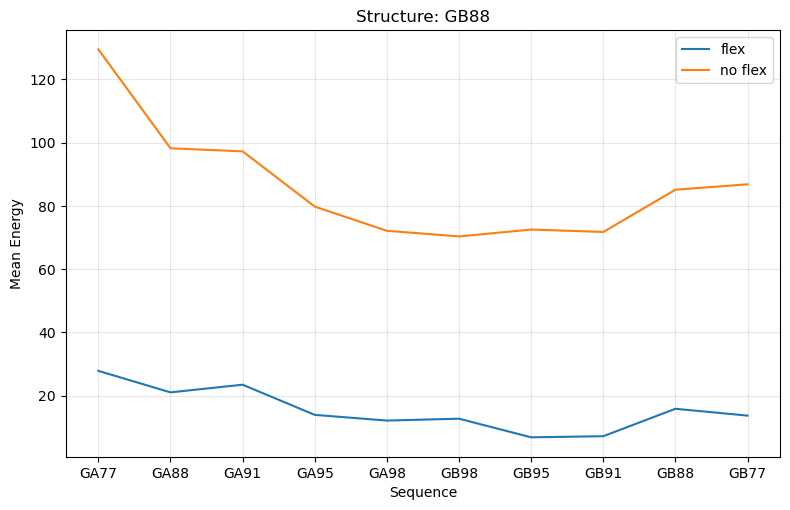

In [40]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sequence_order = ['GA77','GA88','GA91', 'GA95','GA98','GB98', 'GB95','GB91','GB88', 'GB77']

struct = '2jwu'
plot_df = flex_avg_df.loc[sequence_order]
plt.plot(plot_df.index, plot_df[struct], label = 'flex')
plot_df = no_flex_avg_df.loc[sequence_order]
plt.plot(plot_df.index, plot_df[struct], label = 'no flex')

plt.xlabel('Sequence')
plt.ylabel('Mean Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.title("Structure: " + struct_dict[struct])
plt.show()

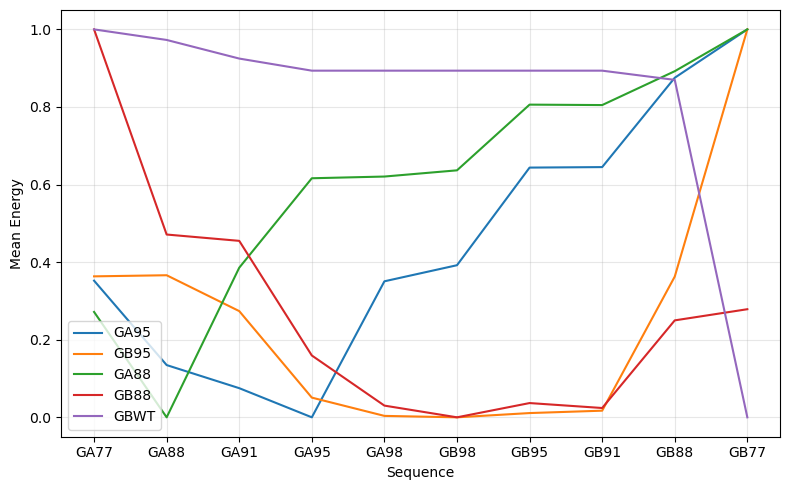

In [58]:
plt.figure(figsize=(8, 5))
sequence_order = ['GA77','GA88','GA91', 'GA95','GA98','GB98', 'GB95','GB91','GB88', 'GB77']

for struct in struct_dict:
    plot_df = no_flex_avg_df.loc[sequence_order]
    plot_energies = np.array(plot_df[struct])
    plot_labels = np.array(plot_df.index)
    plt.plot(plot_labels, plot_energies, label = struct_dict[struct])


plt.xlabel('Sequence')
plt.ylabel('Mean Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

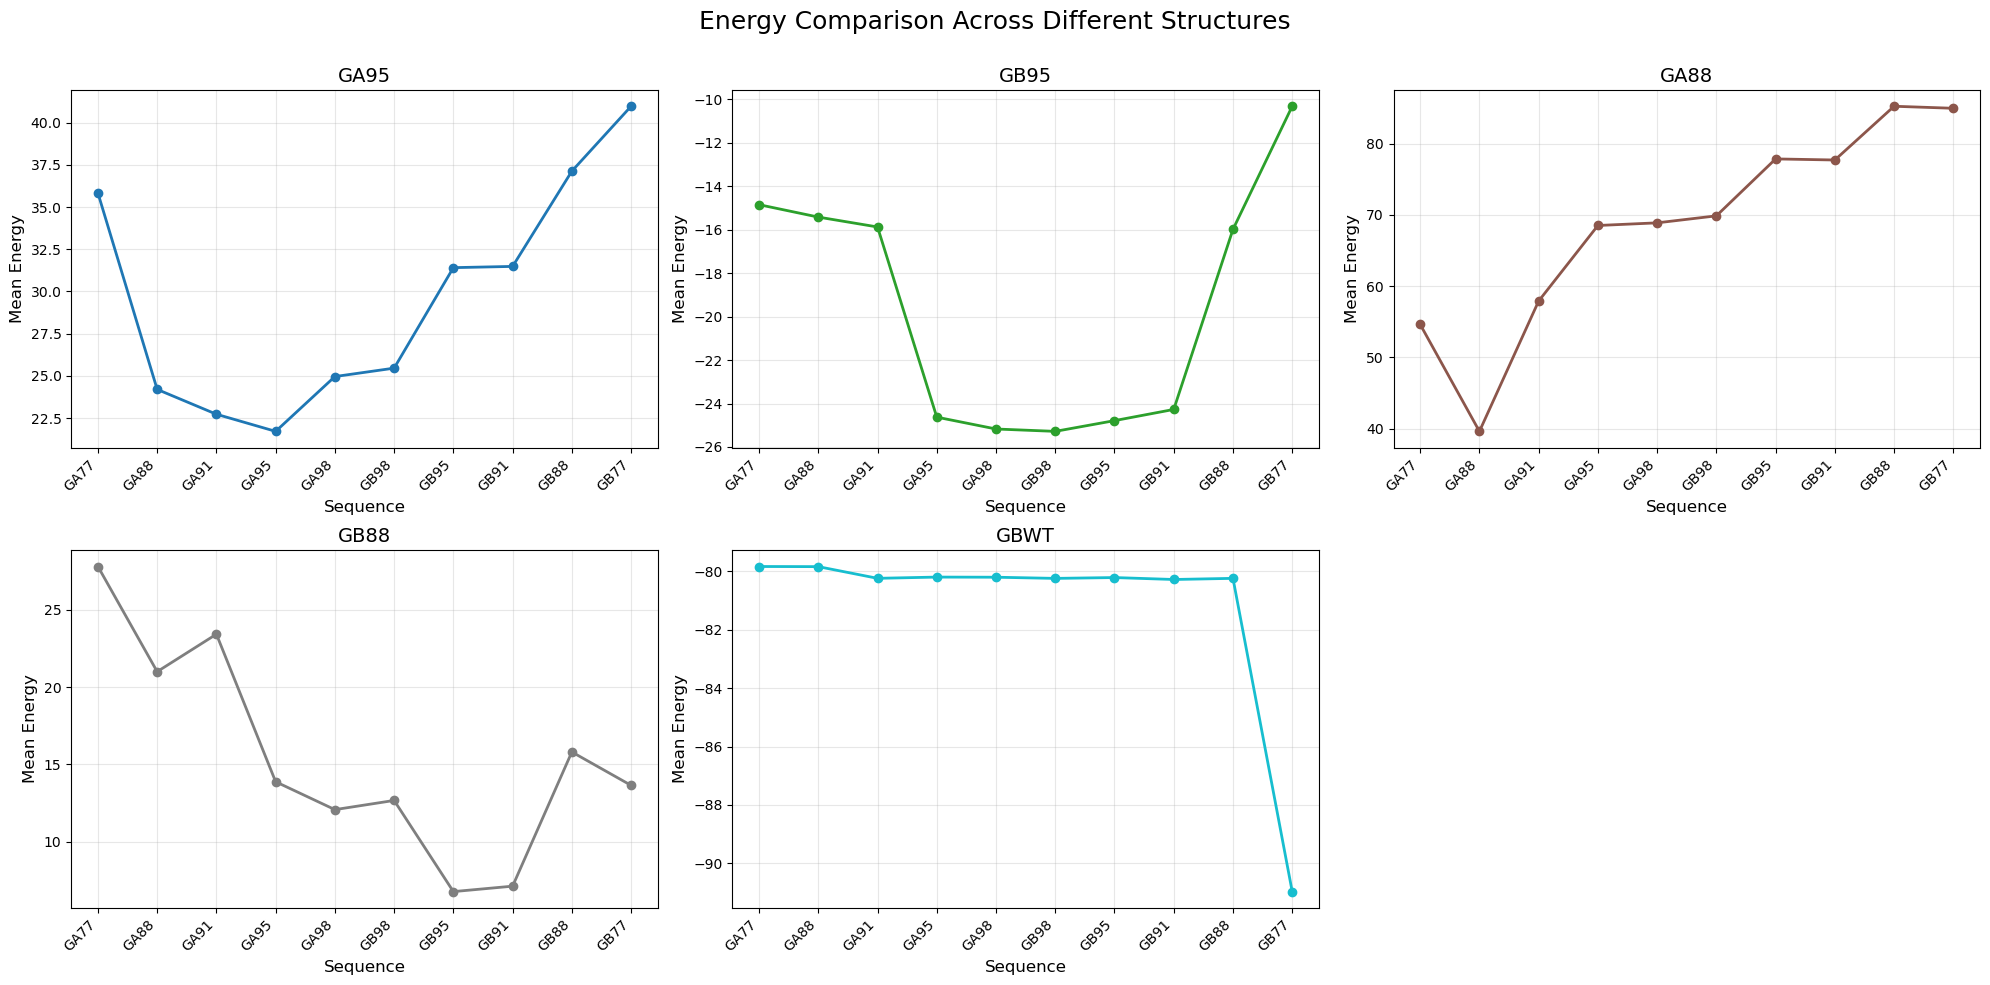

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create a larger figure with better layout
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

sequence_order = ['GA77','GA88','GA91', 'GA95','GA98','GB98', 'GB95','GB91','GB88', 'GB77']
colors = plt.cm.tab10(np.linspace(0, 1, len(struct_dict)))  # Create a color cycle

# Create a subplot for each structure
for i, struct in enumerate(struct_dict):
    if i < len(axs):  # Make sure we don't exceed the number of subplots
        plot_df = flex_avg_df.loc[sequence_order]
        plot_energies = np.array(plot_df[struct])
        plot_labels = np.array(plot_df.index)
        
        # Plot on the corresponding subplot with color cycling
        axs[i].plot(plot_labels, plot_energies, marker='o', color=colors[i], linewidth=2)
        axs[i].set_title(struct_dict[struct], fontsize=14)
        axs[i].grid(True, alpha=0.3)
        
        # Rotate x-axis labels to prevent overcrowding
        axs[i].set_xticks(range(len(plot_labels)))
        axs[i].set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=10)
        
        # Set y-label for all subplots for clarity
        axs[i].set_ylabel('Mean Energy', fontsize=12)
        axs[i].set_xlabel('Sequence', fontsize=12)

# Remove any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

# Add a main title
fig.suptitle('Energy Comparison Across Different Structures', fontsize=18, y=0.98)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Show the plot
plt.show()

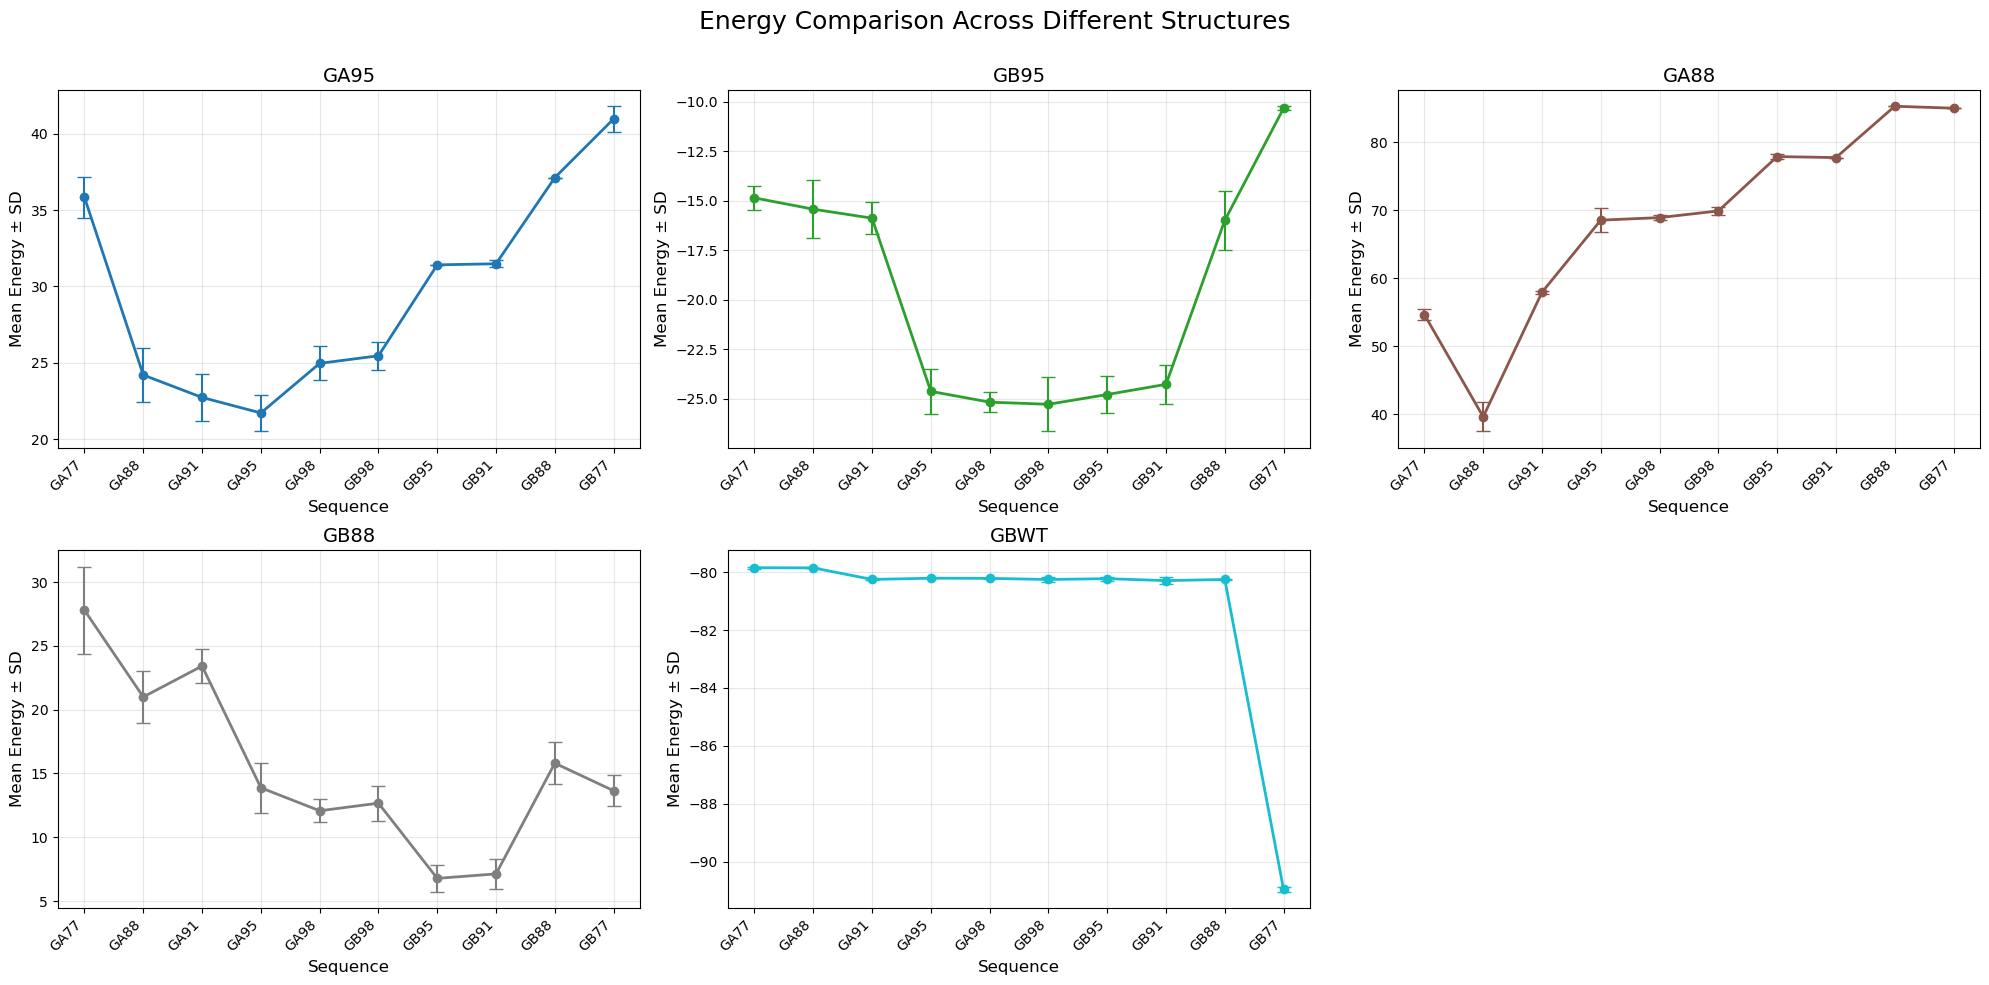

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create a larger figure with better layout
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

sequence_order = ['GA77','GA88','GA91', 'GA95','GA98','GB98', 'GB95','GB91','GB88', 'GB77']
colors = plt.cm.tab10(np.linspace(0, 1, len(struct_dict)))  # Create a color cycle

# Create a subplot for each structure
for i, struct in enumerate(struct_dict):
    if i < len(axs):  # Make sure we don't exceed the number of subplots
        plot_df = flex_avg_df.loc[sequence_order]
        plot_energies = np.array(plot_df[struct])
        plot_labels = np.array(plot_df.index)
        
        # Get the standard deviations from the std DataFrame
        plot_std = np.array(flex_std_df.loc[sequence_order][struct])
        
        # Plot on the corresponding subplot with color cycling and error bars
        axs[i].errorbar(
            range(len(plot_labels)), 
            plot_energies, 
            yerr=plot_std,
            marker='o', 
            color=colors[i], 
            linewidth=2,
            capsize=5,  # Adds caps to the error bars
            ecolor=colors[i],  # Same color as the line
            markersize=6,
            elinewidth=1.5  # Width of the error bar line
        )
        
        axs[i].set_title(struct_dict[struct], fontsize=14)
        axs[i].grid(True, alpha=0.3)
        
        # Rotate x-axis labels to prevent overcrowding
        axs[i].set_xticks(range(len(plot_labels)))
        axs[i].set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=10)
        
        # Set y-label for all subplots for clarity
        axs[i].set_ylabel('Mean Energy ± SD', fontsize=12)  # Updated label to indicate error bars
        axs[i].set_xlabel('Sequence', fontsize=12)

# Remove any unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

# Add a main title
fig.suptitle('Energy Comparison Across Different Structures', fontsize=18, y=0.98)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Show the plot
plt.show()

In [51]:
'GB77' in sequence_order

True

In [50]:
struct_dict[struct]

'GBWT'

In [52]:
np.array(plot_df.index)

array(['GA77', 'GA88', 'GA91', 'GA95', 'GA98', 'GB98', 'GB95', 'GB91',
       'GB88', 'GB77'], dtype=object)